<a href="https://colab.research.google.com/github/baliant/Thesis/blob/main/Generate_Synthetic_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This snippet is for creating synthetic time series data for benchmarking purposes.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
np.random.seed(42)

# Generate hourly timestamps for 2 years
n_hours = 2 * 365 * 24
time_index = pd.date_range(start='2023-01-01', periods=n_hours, freq='h')

# Define periodic functions
def generate_series(periods, amplitudes, noise_std=0.1, trend_slope=0.0):
    """ Generate a synthetic time series with periodic components, a linear trend, and noise.
    Parameters
    ----------
    periods : list of float
        List of periods (in number of time steps) for the sinusoidal components.
    amplitudes : list of float
        List of amplitudes corresponding to each periodic component. Must be the same length as `periods`.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to the signal (default is 0.1).
    trend_slope : float, optional
        Slope of the linear trend to be added to the signal (default is 0.0, i.e., no trend).

    Returns
    -------
    The generated time series as a 1D NumPy array of shape (n_hours).
    The output signal is computed as the sum of sinusoidal components, a linear trend, and random noise.
    Time is assumed to be sampled hourly, with `n_hours` defined globally.
    """
    t = np.arange(n_hours)
    signal = np.zeros_like(t, dtype=float)
    for period, amp in zip(periods, amplitudes):
        signal += amp * np.sin(2 * np.pi * t / period)
    trend = trend_slope * t
    noise = np.random.normal(0, noise_std, size=t.shape)
    return signal + trend + noise

# Periods in hours
yearly = 365 * 24
seasonal = 91.25 * 24
weekly = 7 * 24
daily = 24

# Generate time series
series_1 = generate_series([yearly], [1.0], trend_slope=0.0001)
series_2 = generate_series([yearly, seasonal], [1.0, 0.3], trend_slope=0.0001)
series_3 = generate_series([yearly, seasonal, weekly], [1.0, 0.3, 0.1], trend_slope=0.0001)
series_4 = generate_series([yearly, seasonal, weekly, daily], [1.0, 0.3, 0.1, 0.02], trend_slope=0.0001)


# Create df
df = pd.DataFrame({
    'timestamp': time_index,
    'series_1_yearly': series_1,
    'series_2_yearly_seasonal': series_2,
    'series_3_yearly_seasonal_weekly': series_3,
    'series_4_yearly_seasonal_weekly_daily': series_4
})
df.set_index('timestamp', inplace=True)

# Save to CSV
df.to_csv('synthetic_time_series.csv')



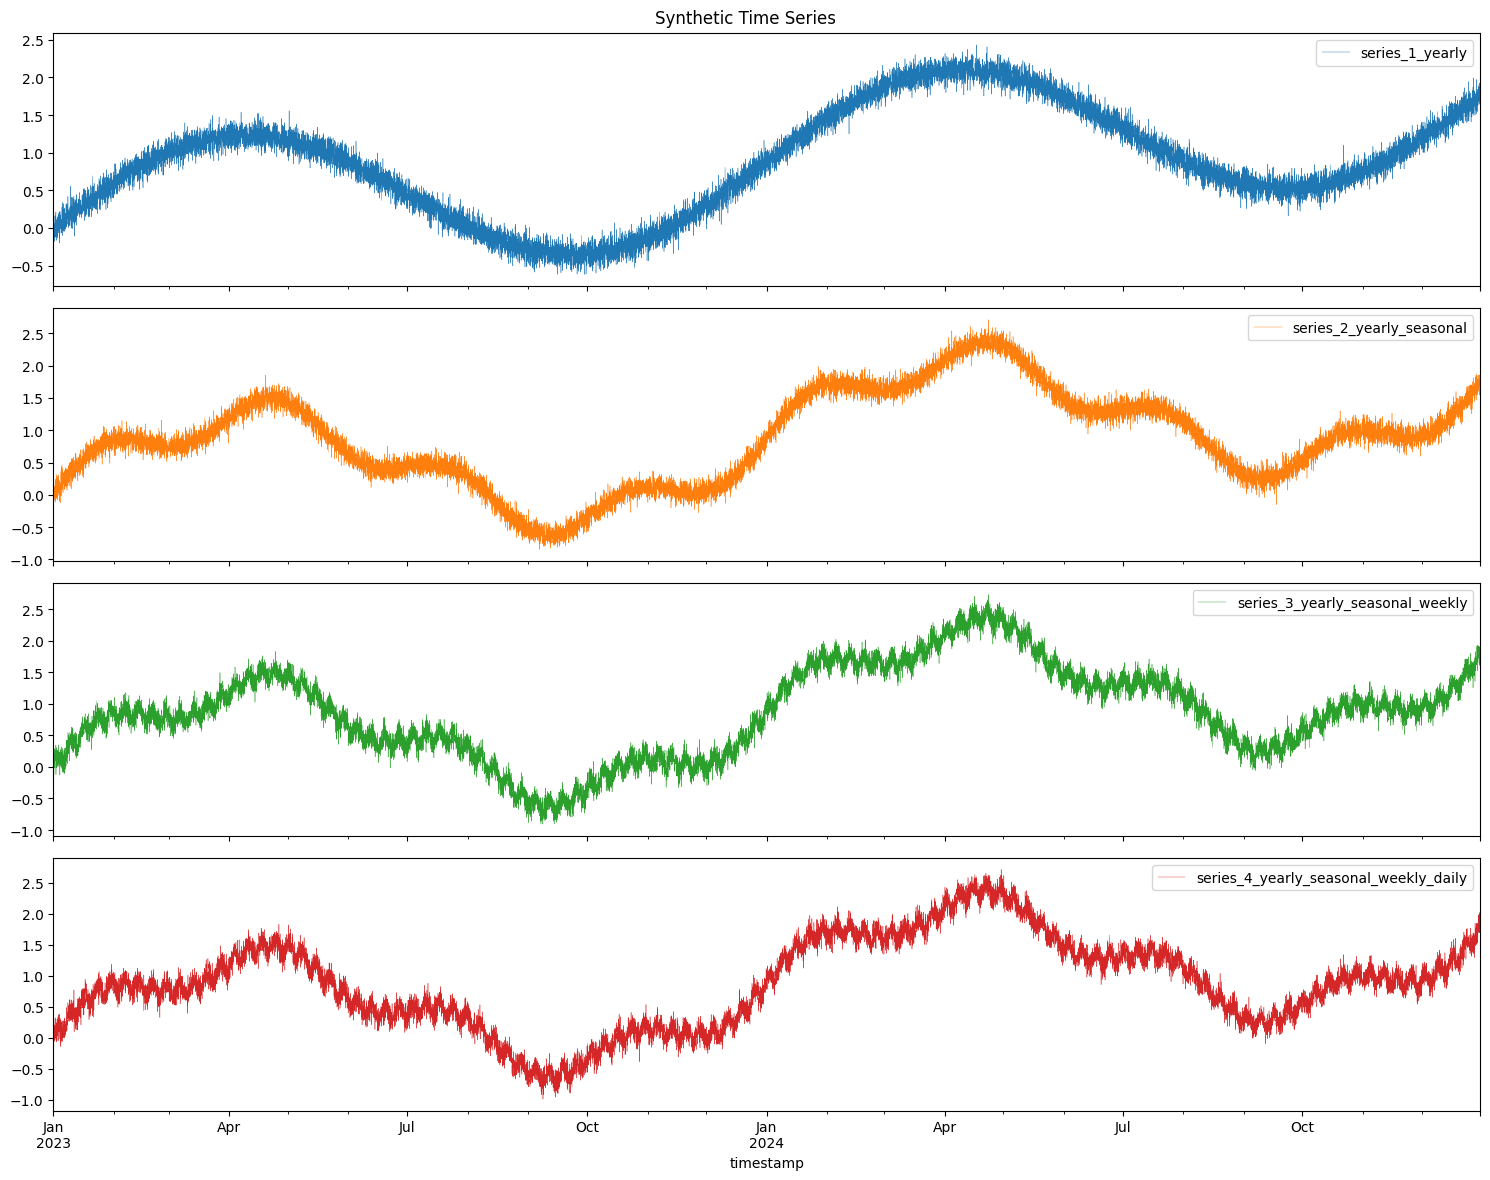

In [26]:
# Plot
df.plot(subplots=True, figsize=(15, 12), title="Synthetic Time Series", linewidth=0.3)
plt.tight_layout()
plt.show()